
**Agent Working (What it Does Internally)**

1. Accepts a user question or research topic via a Gradio interface.

2. Generates research ideas using a locally hosted LLM (phi-2) via a handcrafted prompt.

3. Fetches recent academic papers by querying the arXiv API with the same topic.

4. Combines results into a single response string (ideas + abstracts).

5. Returns the result to the user via the web UI, handling any errors gracefully.


**Agent Features (What It Offers the User)**

1. Research Ideation: Produces 5 structured, novel research ideas for any topic you input.

2. Literature Lookup: Retrieves 3 recent paper abstracts related to your query from arXiv.

3. Runs Without APIs: No OpenAI or Hugging Face API keys needed; works offline or on CPU.

4. User-Friendly Interface: Uses Gradio to offer a simple, web-based input/output system.

5. Safe & Stable on CPU: Optimized for Hugging Face Spaces with response size limits and error handling.



In [1]:
!pip install -q langchain langchain-community transformers accelerate langchain_huggingface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

Phi-2 is a 2.7 billion parameter Transformer model, trained for safety and educational value, intended for QA, chat, and code purposes.


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "microsoft/phi-2"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16).cuda()

input_text = "Suggest 5 novel research ideas in AI for healthcare."
inputs = tokenizer(input_text, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=200)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Suggest 5 novel research ideas in AI for healthcare.
AI: 1. Developing an AI-powered system to automatically detect and diagnose diseases from medical images.
2. Creating an AI-based chatbot to provide personalized healthcare advice and support.
3. Using AI algorithms to analyze large-scale genomic data and identify genetic markers for diseases.
4. Designing an AI system to predict patient outcomes and optimize treatment plans.
5. Developing AI-powered virtual assistants to assist healthcare professionals in administrative tasks.



In [3]:
def generate_research_ideas(llm, tokenizer, topic: str) -> str:
    prompt = f"""You are an AI research assistant.
Suggest 5 **novel and impactful** research ideas on the topic: "{topic}".
For each idea, provide:
1. Title
2. Problem Description
3. Proposed Approach
4. Innovation
5. Potential Impact
"""

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    output = llm.generate(**inputs, max_new_tokens=512)
    response = tokenizer.decode(output[0], skip_special_tokens=True)
    return response


In [4]:
def rank_research_ideas(llm, tokenizer, ideas_text: str) -> str:
    prompt = f"""You are a research evaluation agent.
Evaluate and rank the following research ideas from most to least innovative.

Here are the ideas:
{ideas_text}

Provide a ranking and short reasoning.
"""
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    output = llm.generate(**inputs, max_new_tokens=256)
    response = tokenizer.decode(output[0], skip_special_tokens=True)
    return response


In [5]:
def research_idea_agent(llm, tokenizer, topic: str):
    print(f" Generating ideas for: {topic}")
    ideas = generate_research_ideas(llm, tokenizer, topic)
    print("\n Raw Ideas:\n", ideas)

    print("\n Evaluating and ranking ideas...")
    ranked = rank_research_ideas(llm, tokenizer, ideas)
    print("\n Ranked Output:\n", ranked)


In [6]:
topic = "Reinforcement Learning in Healthcare"
research_idea_agent(model, tokenizer, topic)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


 Generating ideas for: Reinforcement Learning in Healthcare


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



 Raw Ideas:
 You are an AI research assistant.
Suggest 5 **novel and impactful** research ideas on the topic: "Reinforcement Learning in Healthcare".
For each idea, provide:
1. Title
2. Problem Description
3. Proposed Approach
4. Innovation
5. Potential Impact
1. Title: "Reinforcement Learning for Personalized Treatment Plans in Cancer Patients"
Problem Description: Cancer treatment is a complex and individualized process, with each patient responding differently to various treatments. Traditional treatment plans are often based on general guidelines and may not take into account the unique characteristics of each patient. This can lead to suboptimal treatment outcomes and increased side effects.
Proposed Approach: Reinforcement learning can be used to develop personalized treatment plans for cancer patients. By training an agent to learn from patient data, such as genetic information, medical history, and treatment responses, the agent can generate treatment plans that are tailored t

In [16]:
# Install Dependencies
!pip install transformers torch gradio requests --quiet

# Load Phi-2 Model (GPU)
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "microsoft/phi-2"
#model_id = "microsoft/phi-1_5"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float16).cuda()

# Memory store
memory = []

# Tool: Generate Research Ideas
def generate_ideas(topic):
    prompt = f"""
Suggest 5 novel research ideas on the topic: "{topic}".
For each idea, include:
1. Title
2. Problem
3. Proposed Method
4. Innovation
5. Potential Impact
"""
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=512)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Tool: Evaluate Ideas
def evaluate_ideas(ideas_text):
    prompt = f"""Evaluate and rank these research ideas:
{ideas_text}

Rank them by novelty and impact. Provide reasoning."""
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=300)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Tool: arXiv Abstract Retriever (no API key)
import requests
from bs4 import BeautifulSoup

def get_arxiv_abstracts(query):
    url = f"http://export.arxiv.org/api/query?search_query=all:{query}&start=0&max_results=3"
    response = requests.get(url)
    soup = BeautifulSoup(response.content, features="xml")
    entries = soup.find_all('entry')
    abstracts = "\n\n".join([f"📄 {e.title.text}\n{e.summary.text.strip()}" for e in entries])
    return abstracts or "No papers found."

# 🔁 Agent Core Logic
def agent(topic):
    ideas = generate_ideas(topic)
    ranking = evaluate_ideas(ideas)
    papers = get_arxiv_abstracts(topic)

    # Save to memory
    memory.append({"topic": topic, "ideas": ideas})

    return f"Research Ideas:\n{ideas}\n\n📊 Evaluation:\n{ranking}\n\n📚 Relevant Papers:\n{papers}"


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [17]:
import gradio as gr

def gradio_agent_interface(topic):
    return agent(topic)

with gr.Blocks() as demo:
    gr.Markdown("##  Research Idea Agent")
    topic_input = gr.Textbox(label="Enter Research Topic")
    output_box = gr.Textbox(label="Agent Output", lines=20)
    submit_btn = gr.Button("Generate Ideas")

    submit_btn.click(fn=gradio_agent_interface, inputs=topic_input, outputs=output_box)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://59756cf6fc96fda837.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [18]:
from transformers import pipeline
from langchain_community.llms import HuggingFacePipeline
from langchain.agents import initialize_agent, Tool
from langchain.agents.agent_types import AgentType

#  Create a proper transformers pipeline
hf_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    torch_dtype=torch.float16,
    device=0   # CUDA device
)

#  Wrap that pipeline for LangChain
llm_chain = HuggingFacePipeline(pipeline=hf_pipeline)

#  Define tools (these work as expected)
tools = [
    Tool(name="GenerateIdeas", func=lambda x: generate_ideas(x), description="Generate research ideas"),
    Tool(name="ArxivRetriever", func=lambda x: get_arxiv_abstracts(x), description="Get recent paper abstracts")
]

#  Create the agent
agent = initialize_agent(
    tools=tools,
    llm=llm_chain,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)

#  Call the agent (deprecated `.run`, use `.invoke` in new versions)
response = agent.invoke("Find recent trends in AI for smart healthcare and suggest 5 research ideas.")
print(response)

Device set to use cuda:0
/tmp/ipython-input-747663193.py:16: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm_chain = HuggingFacePipeline(pipeline=hf_pipeline)
/tmp/ipython-input-747663193.py:25: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loop workflows. For details, refer to the `LangGraph documentation <https://langchain-ai.github.io/langgraph/>`_ as well as guides for `Migrating from AgentExecutor 



> Entering new AgentExecutor chain...


ValueError: An output parsing error occurred. In order to pass this error back to the agent and have it try again, pass `handle_parsing_errors=True` to the AgentExecutor. This is the error: Parsing LLM output produced both a final answer and a parse-able action:: Answer the following questions as best you can. You have access to the following tools:

GenerateIdeas(x) - Generate research ideas
ArxivRetriever(x) - Get recent paper abstracts

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [GenerateIdeas, ArxivRetriever]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: Find recent trends in AI for smart healthcare and suggest 5 research ideas.
Thought: Use Arxi

In [ ]:
# !pip install transformers torch langchain langchain-community langchain-huggingface bs4 requests --quiet

In [19]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

model_id = "microsoft/phi-2"
#model_id = "microsoft/phi-1_5"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, torch_dtype=torch.float16
).cuda()

# Wrap model in HF pipeline
hf_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    torch_dtype=torch.float16,
    device=0
)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


In [22]:
from langchain_huggingface import HuggingFacePipeline
from langchain.agents import initialize_agent, Tool
from langchain.agents.agent_types import AgentType

llm_chain = HuggingFacePipeline(pipeline=hf_pipeline)


In [23]:
import requests
from bs4 import BeautifulSoup

# Tool 1: Generate Research Ideas
def generate_ideas(topic):
    prompt = f"""Suggest 5 novel research ideas on the topic "{topic}".
Each idea must include:
1. Title
2. Problem
3. Proposed Method
4. Innovation
5. Potential Impact"""
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=512)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Tool 2: Retrieve Arxiv Papers
def get_arxiv_abstracts(query):
    url = f"http://export.arxiv.org/api/query?search_query=all:{query}&start=0&max_results=3"
    response = requests.get(url)
    soup = BeautifulSoup(response.content, features="xml")
    entries = soup.find_all('entry')
    abstracts = "\n\n".join([f"📄 {e.title.text}\n{e.summary.text.strip()}" for e in entries])
    return abstracts or "No papers found."

# LangChain tool wrappers
tools = [
    Tool(name="GenerateIdeas", func=generate_ideas, description="Generate research ideas from a topic"),
    Tool(name="ArxivRetriever", func=get_arxiv_abstracts, description="Get recent paper abstracts from arXiv")
]


In [24]:
# Custom prompt to force ReAct format
custom_prefix = """Answer the following questions as best you can. You have access to the following tools:

GenerateIdeas: Generate research ideas
ArxivRetriever: Get recent paper abstracts

Use the following format:

Question: the input question
Thought: think about what to do
Action: the action to take, should be one of [GenerateIdeas, ArxivRetriever]
Action Input: the input to the action (as a string)
Observation: the result of the action
... (repeat Thought/Action/Action Input/Observation as needed)
Thought: I now know the final answer
Final Answer: the final answer to the question

Begin!
"""

agent = initialize_agent(
    tools=tools,
    llm=llm_chain,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    handle_parsing_errors=True,  # this avoids crashes
    verbose=True,
    agent_kwargs={"prefix": custom_prefix}
)


In [25]:
query = "Find recent trends in AI for smart healthcare and suggest 5 research ideas."
response = agent.invoke(query)
print("\n Agent Response:\n", response)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.




> Entering new AgentExecutor chain...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Parsing LLM output produced both a final answer and a parse-able action:: Answer the following questions as best you can. You have access to the following tools:

GenerateIdeas: Generate research ideas
ArxivRetriever: Get recent paper abstracts

Use the following format:

Question: the input question
Thought: think about what to do
Action: the action to take, should be one of [GenerateIdeas, ArxivRetriever]
Action Input: the input to the action (as a string)
Observation: the result of the action
... (repeat Thought/Action/Action Input/Observation as needed)
Thought: I now know the final answer
Final Answer: the final answer to the question

Begin!


GenerateIdeas(topic) - Generate research ideas from a topic
ArxivRetriever(query) - Get recent paper abstracts from arXiv

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [GenerateIdeas, ArxivRetriever]
Action Input: the in

Token indices sequence length is longer than the specified maximum sequence length for this model (2273 > 2048). Running this sequence through the model will result in indexing errors
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
This is a friendly reminder - the current text generation call will exceed the model's predefined maximum length (2048). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


...

Parsing LLM output produced both a final answer and a parse-able action:: Answer the following questions as best you can. You have access to the following tools:

GenerateIdeas: Generate research ideas
ArxivRetriever: Get recent paper abstracts

Use the following format:

Question: the input question
Thought: think about what to do
Action: the action to take, should be one of [GenerateIdeas, ArxivRetriever]
Action Input: the input to the action (as a string)
Observation: the result of the action
... (repeat Thought/Action/Action Input/Observation as needed)
Thought: I now know the final answer
Final Answer: the final answer to the question

Begin!


GenerateIdeas(topic) - Generate research ideas from a topic
ArxivRetriever(query) - Get recent paper abstracts from arXiv

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [GenerateIdeas, ArxivRetriever]
Action Input: the in

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Parsing LLM output produced both a final answer and a parse-able action:: Answer the following questions as best you can. You have access to the following tools:

GenerateIdeas: Generate research ideas
ArxivRetriever: Get recent paper abstracts

Use the following format:

Question: the input question
Thought: think about what to do
Action: the action to take, should be one of [GenerateIdeas, ArxivRetriever]
Action Input: the input to the action (as a string)
Observation: the result of the action
... (repeat Thought/Action/Action Input/Observation as needed)
Thought: I now know the final answer
Final Answer: the final answer to the question

Begin!


GenerateIdeas(topic) - Generate research ideas from a topic
ArxivRetriever(query) - Get recent paper abstracts from arXiv

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [GenerateIdeas, ArxivRetriever]
Action Input: the in

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.50 GiB. GPU 0 has a total capacity of 39.56 GiB of which 1.16 GiB is free. Process 34381 has 38.38 GiB memory in use. Of the allocated memory 34.42 GiB is allocated by PyTorch, and 3.47 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import gradio as gr

#  Memory for the session
chat_history = []

#  Agent handler
def agent_interface(user_input):
    if not user_input.strip():
        return "Please enter a question or research topic."

    # Call the LangChain agent
    try:
        result = agent.invoke(user_input)
    except Exception as e:
        result = f" Error: {str(e)}"

    # Store history (simple list)
    chat_history.append((user_input, result))

    # Display full chat
    chat_transcript = "\n\n".join([f" {q}\n {a}" for q, a in chat_history])
    return chat_transcript

#  Launch Gradio interface
with gr.Blocks() as demo:
    gr.Markdown("##  AI Research Assistant (Powered by phi-2, LangChain)")
    with gr.Row():
        user_input = gr.Textbox(label="Enter a research question or topic", lines=2)
    output_box = gr.Textbox(label="Conversation History", lines=20)
    submit_btn = gr.Button("Submit")

    submit_btn.click(fn=agent_interface, inputs=user_input, outputs=output_box)

demo.launch(share=True)


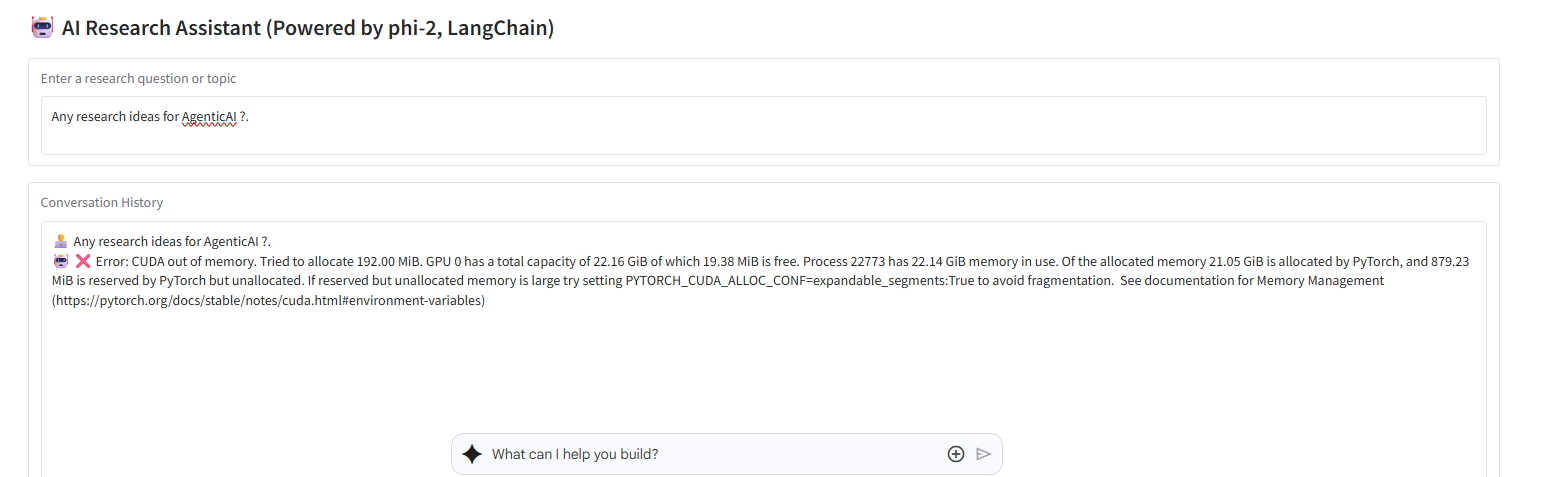